In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [42]:
from preprocessing import get_data, get_encoded_data, split_data

features, target = get_data()
encoded_features, target = get_encoded_data(features, target)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(encoded_features, target)

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(dim=1).to(device)

X_valid = torch.tensor(X_valid.values, dtype=torch.float32).to(device)
y_valid = torch.tensor(y_valid.values, dtype=torch.float32).unsqueeze(dim=1).to(device)

In [33]:
X_train.shape, y_train.shape

(torch.Size([5625, 12]), torch.Size([5625, 1]))

In [36]:
class ChurnModel(nn.Module):
    def __init__(self):
        super(ChurnModel, self).__init__()
        self.layer1 = nn.Linear(X_train.shape[1], 64)
        self.layer2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.out(x)
        x = self.sigmoid(x)
        
        return x

In [37]:
model = ChurnModel().to(device)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [55]:
# 학습
model.train()
for epoch in range(1000):
    # 순전파
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    # 역전파
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
print("완료")

완료


In [56]:
y_pred = model(X_valid)

/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


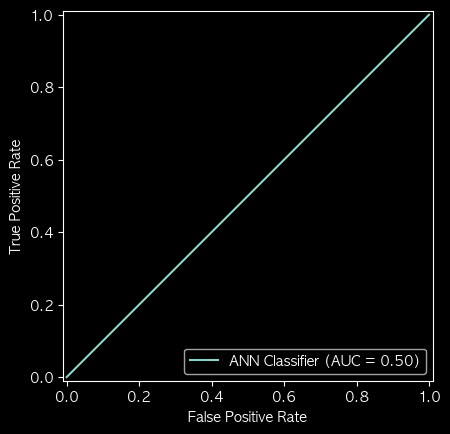

In [57]:
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

y_valid_np = y_valid.detach().cpu().numpy()
y_pred_np = y_pred.detach().cpu().numpy()

rfc_roc = roc_auc_score(y_valid_np, y_pred_np)
fpr, tpr, thresh = roc_curve(y_valid_np, y_pred_np)

disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=tpr,
    roc_auc=rfc_roc,
    estimator_name='ANN Classifier'
)
disp_roc_rfc.plot()
plt.show()